In [2]:
import sys
sys.path.append('../..')
import pyFidA
import matplotlib.pyplot as plt

## Load and Plot Data

In [3]:
out1=pyFidA.io_loadspec_bruk('../../exampleData/bruker/rawdata.job0')
print(out1)

FID has fids size (2048, 4, 250) and dimensions: t, coils, averages


/Users/nearlabmacbook1/opt/anaconda3/envs/scicomp/lib/python3.9/site-packages/spec2nii/bruker.py:204: UserWarning: The orientation of bruker fid data is mostly untested.
  warnings.warn('The orientation of bruker fid data is mostly untested.')


The data have 2048 time/frequency points, 4 coils and 250 averages. We will need to combine the data from the four receive coils, then average. First, let's look at the data.

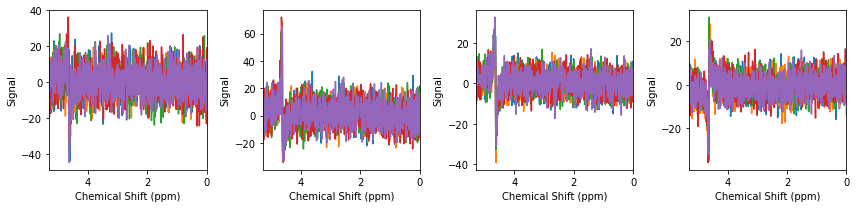

In [4]:
# Plot selected averages (eg. every 50th average) for each coil
f1,ax1=plt.subplots(1,4)
f1.set_size_inches([12,3])
for coil_count in range(out1.sz[out1.dims['coils']]):
    out1[:,coil_count,::50].plot_spec(xlims=[5.3,0],plotax=ax1[coil_count])
f1.tight_layout()

FID has fids size (2048,) and dimensions: t


/Users/nearlabmacbook1/opt/anaconda3/envs/scicomp/lib/python3.9/site-packages/spec2nii/bruker.py:204: UserWarning: The orientation of bruker fid data is mostly untested.
  warnings.warn('The orientation of bruker fid data is mostly untested.')


Text(0.5, 1.0, 'Reference Spectrum (phased)')

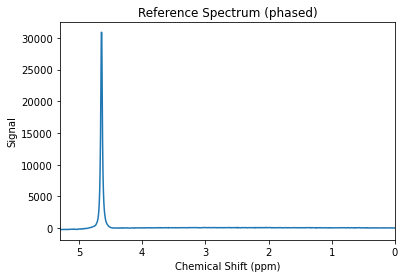

In [5]:
# Plot the reference spectrum
ref1=pyFidA.io_loadspec_bruk('../../exampleData/bruker/fid.refscan')
print(ref1)
# Plot, after trying to phase
pyFidA.op_autophase(ref1,return_extra_args=False).plot_spec([5.3,0])
plt.title('Reference Spectrum (phased)')

The data for the individual averages in the metabolite data are very noisy. Only the water peak around 4.6 ppm is evident. However, the coil combination function will use the averages for each coil to calculate the phase and scaling parameters needed for combination.

## Combine Coils

<AxesSubplot:xlabel='Chemical Shift (ppm)', ylabel='Signal'>

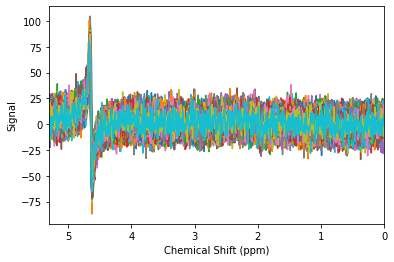

In [6]:
fid1_cc,fids_presum,specs_presum,coilcombos=pyFidA.op_addrcvrs(out1)
fid1_cc.plot_spec([5.3,0])

## Combine all 250 averages

<AxesSubplot:xlabel='Chemical Shift (ppm)', ylabel='Signal'>

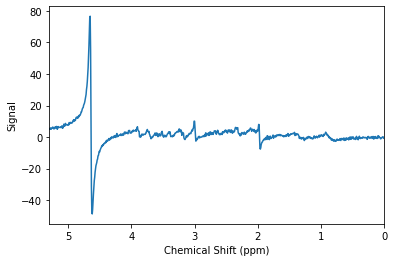

In [7]:
fid1_avg=pyFidA.op_averaging(fid1_cc)
fid1_avg.plot_spec([5.3,0])

The data are out of phase. We can select a peak to calculate the phase, for example creatine around 3 ppm or the water peak around 4.6 ppm.

-47.97552610864439 -76.41699286729133


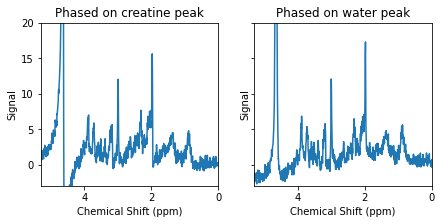

In [8]:
f1,ax1=plt.subplots(1,2,sharey=True)
f1.set_size_inches(7,3)
fid1_phased_Cr,ph1=pyFidA.op_autophase(fid1_avg,2.8,3.1)
fid1_phased_Cr.plot_spec(xlims=[5.3,0],plotax=ax1[0],title='Phased on creatine peak')
fid1_phased_water,ph2=pyFidA.op_autophase(fid1_avg,4.3,4.9)
fid1_phased_water.plot_spec(xlims=[5.3,0],plotax=ax1[1],title='Phased on water peak')
ax1[0].set_ylim([-3,20])
print(ph1,ph2)